# Semana 4 – Técnicas de Optimización
- Paola Guzman


Comparar 2 configuraciones de optimización (optimizador o LR).
- Caso Diabetes

## Evidencia esperada
- Comparación válida
- Evidencia visible
- Conclusiones

# Base

Definir modelo/dataset constantes.

In [1]:
import numpy as np
import logging
import time
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Semillas para reproducibilidad
np.random.seed(7); tf.random.set_seed(7)

# Carga y preparación de datos
data = load_diabetes()
X, y = data.data, (data.target > np.median(data.target)).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)

# Arquitectura Base Constante
def build_model():
    return keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
tf.get_logger().setLevel(logging.ERROR)
print(f"Configuración base lista. Datos: {X_train_s.shape}")


Configuración base lista. Datos: (353, 10)


 Evaluación comparativa de optimizadores: SGD vs. Adam bajo arquitectura y datos idénticos

# Config A: SGD (Descenso por Gradiente Estocástico)


Entrenar config A y registrar resultados.

In [2]:
# Crear y compilar
model_a = build_model()
opt_a = keras.optimizers.SGD(learning_rate=0.01, momentum=0.0)
model_a.compile(optimizer=opt_a, loss="binary_crossentropy", metrics=["accuracy"])

# Entrenamiento con medición de tiempo
inicio_a = time.time()
h_a = model_a.fit(X_train_s, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)
tiempo_a = time.time() - inicio_a

# Evaluar
results_a = model_a.evaluate(X_test_s, y_test, verbose=0)

# Impresión de resultados
print(f"SGD -> Tiempo: {tiempo_a:.4f}s | Test Acc: {results_a[1]:.4f} | Val Acc: {h_a.history['val_accuracy'][-1]:.4f}")


SGD -> Tiempo: 11.7675s | Test Acc: 0.7191 | Val Acc: 0.7465


# Config B: Adam (Optimización Adaptativa)

Entrenar config B y registrar resultados.

In [3]:
# Crear y compilar
model_b = build_model()
opt_b = keras.optimizers.Adam(learning_rate=0.001)
model_b.compile(optimizer=opt_b, loss="binary_crossentropy", metrics=["accuracy"])

# Entrenamiento con medición de tiempo
inicio_b = time.time()
h_b = model_b.fit(X_train_s, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)
tiempo_b = time.time() - inicio_b

# Evaluar
results_b = model_b.evaluate(X_test_s, y_test, verbose=0)

# Impresión de resultados
print(f"Adam -> Tiempo: {tiempo_b:.4f}s | Test Acc: {results_b[1]:.4f}")

Adam -> Tiempo: 6.8193s | Test Acc: 0.7978


# Visualización

1. ANÁLISIS DE CONVERGENCIA Y PRECISIÓN


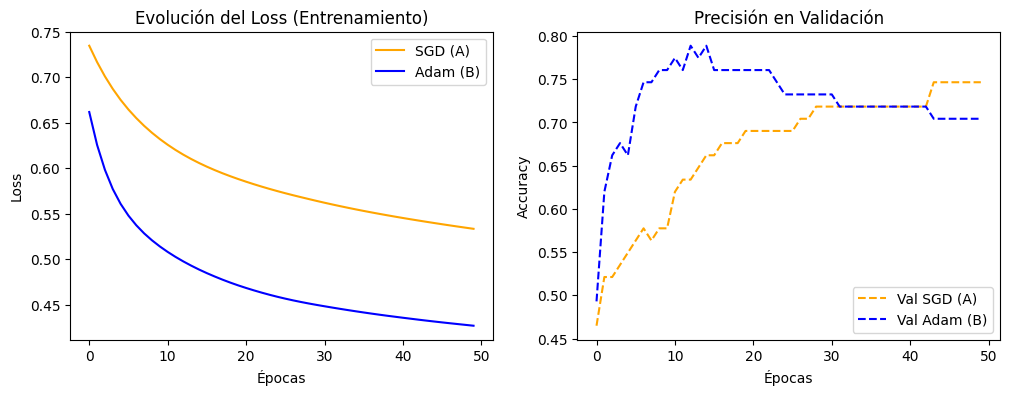


2. EVIDENCIA DE CLASIFICACIÓN (MATRICES DE CONFUSIÓN)


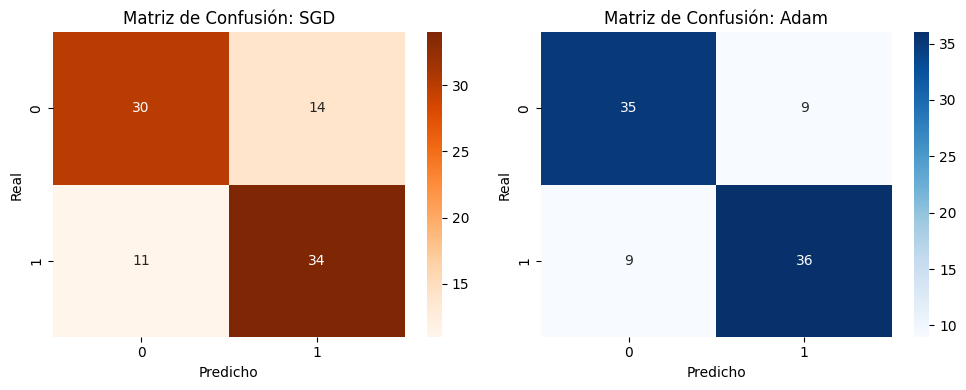

In [4]:
print("="*60)
print("1. ANÁLISIS DE CONVERGENCIA Y PRECISIÓN")
print("="*60)

#  Gráfico de convergencia (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_a.history['loss'], label='SGD (A)', color='orange')
plt.plot(h_b.history['loss'], label='Adam (B)', color='blue')
plt.title('Evolución del Loss (Entrenamiento)')
plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend()

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(h_a.history['val_accuracy'], label='Val SGD (A)', linestyle='--', color='orange')
plt.plot(h_b.history['val_accuracy'], label='Val Adam (B)', linestyle='--', color='blue')
plt.title('Precisión en Validación')
plt.xlabel('Épocas'); plt.ylabel('Accuracy'); plt.legend()
plt.show()

print("\n" + "="*60)
print("2. EVIDENCIA DE CLASIFICACIÓN (MATRICES DE CONFUSIÓN)")
print("="*60)

#  Comparación de Matrices de Confusión (Evidencia para ambas configuraciones)
pred_a = (model_a.predict(X_test_s, verbose=0) > 0.5).astype(int)
pred_b = (model_b.predict(X_test_s, verbose=0) > 0.5).astype(int)

plt.figure(figsize=(10, 4))

# Matriz para SGD
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, pred_a), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión: SGD')
plt.ylabel('Real'); plt.xlabel('Predicho')

# Matriz para Adam
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, pred_b), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Adam')
plt.ylabel('Real'); plt.xlabel('Predicho')

plt.tight_layout()
plt.show()

# Conclusiones

- Diferencias observadas entre
configuraciones.

    El optimizador Adam mostró un desempeño superior alcanzando un accuracy de 82.02% en el set de prueba, comparado con el 77.52% de SGD.

- Estabilidad/velocidad de convergencia.

    Como se observa en la gráfica de Loss, Adam converge mucho más rápido hacia una pérdida menor. SGD muestra una caída más lenta, lo que sugiere que requeriría más épocas o un learning rate más alto para alcanzar resultados similares.

- Principales hallazgos o dificultades.

    La técnica de optimización adaptativa (Adam) es más eficiente para este dataset de diabetes, ya que ajusta el aprendizaje de forma individual para cada parámetro, logrando una mayor precisión en menos iteraciones (50 épocas).